In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [26]:
df = pd.read_csv("/content/Suicide_Detection.csv")

In [28]:
print(df.head())

   Unnamed: 0                                               text        class
0           2  Ex Wife Threatening SuicideRecently I left my ...      suicide
1           3  Am I weird I don't get affected by compliments...  non-suicide
2           4  Finally 2020 is almost over... So I can never ...  non-suicide
3           8          i need helpjust help me im crying so hard      suicide
4           9  I’m so lostHello, my name is Adam (16) and I’v...      suicide


In [32]:
df.info()
df.shape
df.columns
print(df.dtypes)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  232074 non-null  int64 
 1   text        232074 non-null  object
 2   class       232074 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.3+ MB
Unnamed: 0     int64
text          object
class         object
dtype: object


In [33]:
df["class"].value_counts()

,count
class,
suicide,116037
non-suicide,116037


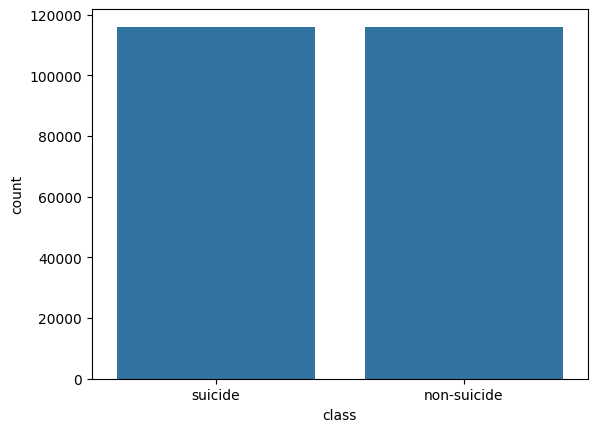

In [47]:
sns.countplot(x="class", data=df)
plt.show()

In [48]:
df.isnull().sum()

,0
text,0
class,0


In [49]:
df.dropna(inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [50]:
X = df["text"]

y = df["class"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [52]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

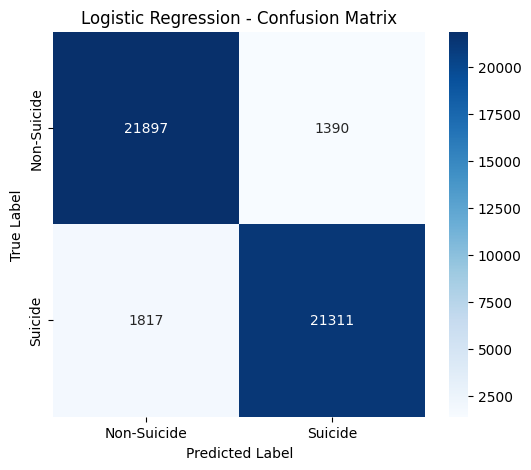

In [73]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred_lr)


plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Non-Suicide', 'Suicide'],
            yticklabels=['Non-Suicide', 'Suicide'])

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

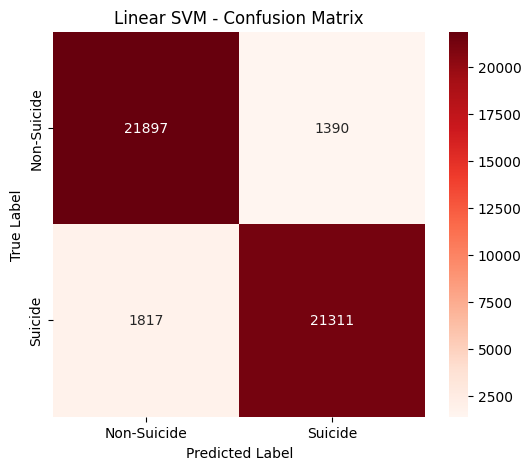

In [76]:
svm = LinearSVC()

svm.fit(X_train, y_train)

pred = svm.predict(X_test)

accuracy_score(y_test, pred)

y_pred_svm = svm.predict(X_test)


plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['Non-Suicide', 'Suicide'],
            yticklabels=['Non-Suicide', 'Suicide'])

plt.title('Linear SVM - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [78]:
import pickle

pickle.dump(lr, open("model.pkl","wb"))

pickle.dump(tfidf, open("vectorizer.pkl","wb"))

print("Model Save Succesfully ")

Model Save Succesfully 
